<a href="https://colab.research.google.com/github/eyabouebsa/greenova-ESSTHS-iastam6.0/blob/main/greenova_ESSTHS_iastam6.0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision -q

In [ ]:
import torch
import torchvision.models as models

# Charger MobileNetV2 déjà entraîné sur ImageNet
model = models.mobilenet_v2(weights="IMAGENET1K_V1")
model.eval()  # mode évaluation (pas d'entraînement pour l'instant)

print("Modèle chargé avec succès !")
print(model.classifier)  # affiche la dernière couche du modèle

Modèle chargé avec succès !
Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)


In [ ]:
!pip install torchgeo -q

In [ ]:
from torchgeo.datasets import EuroSAT

# Télécharge automatiquement le dataset EuroSAT (RGB)
dataset = EuroSAT(root="./data", download=True, split="train")

print(f"Nombre d'images dans le dataset : {len(dataset)}")
print(f"Classes disponibles : {dataset.classes}")


Nombre d'images dans le dataset : 16200
Classes disponibles : ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


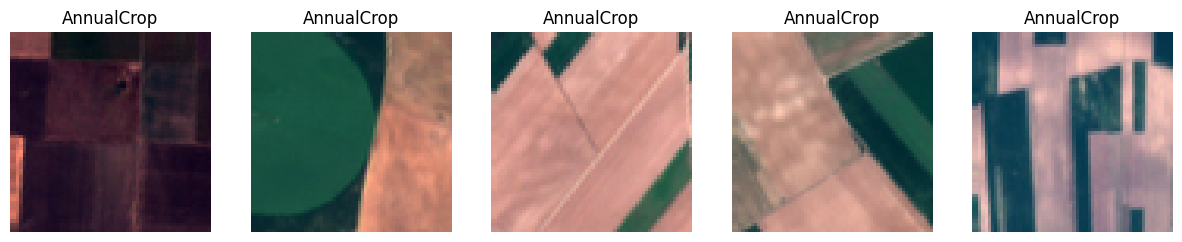

In [ ]:
import matplotlib.pyplot as plt

# Afficher 5 images avec leur label
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i in range(5):
    sample = dataset[i]
    image = sample["image"]  # tenseur image
    label = sample["label"]  # index de la classe

    # Convertir le tenseur en format affichable (les images EuroSAT ont 13 bandes, on prend RGB)
    img = image[[3, 2, 1], :, :].permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())  # normaliser pour affichage

    axes[i].imshow(img)
    axes[i].set_title(dataset.classes[label])
    axes[i].axis("off")

plt.show()

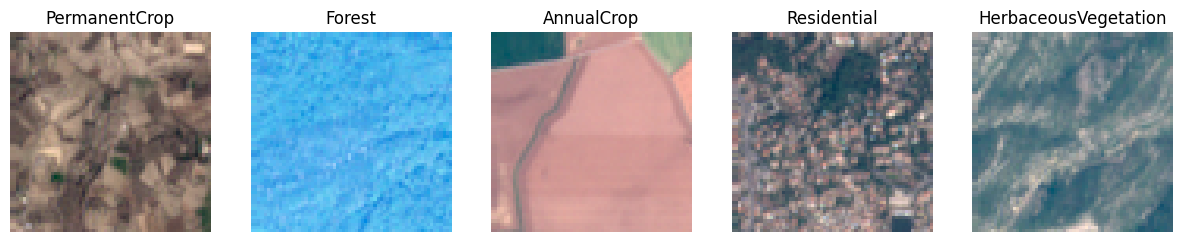

In [ ]:
import matplotlib.pyplot as plt
import random

# Choisir 5 images AU HASARD pour voir plusieurs classes différentes
random.seed(42)
indices = random.sample(range(len(dataset)), 5)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i, idx in enumerate(indices):
    sample = dataset[idx]
    image = sample["image"]
    label = sample["label"]

    img = image[[3, 2, 1], :, :].permute(1, 2, 0).numpy()

    # Meilleure normalisation : on utilise les percentiles pour des couleurs plus naturelles
    p2, p98 = img.min(), img.max()
    img = (img - p2) / (p98 - p2)
    img = img.clip(0, 1) ** 0.6  # légère correction gamma pour éclaircir

    axes[i].imshow(img)
    axes[i].set_title(dataset.classes[label])
    axes[i].axis("off")

plt.show()

In [ ]:
import torch.nn as nn

# Remplacer la dernière couche du modèle : 1000 classes → 10 classes
num_classes = len(dataset.classes)  # 10
model.classifier[1] = nn.Linear(model.last_channel, num_classes)

print("Nouvelle dernière couche :")
print(model.classifier)

Nouvelle dernière couche :
Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=10, bias=True)
)


In [ ]:
from torch.utils.data import DataLoader, Subset
import numpy as np

np.random.seed(42)
all_indices = np.random.permutation(len(dataset))

train_indices = all_indices[:2000]
test_indices = all_indices[2000:2500]

train_subset = Subset(dataset, train_indices)
test_subset = Subset(dataset, test_indices)

def collate_fn(batch):
    images = torch.stack([item["image"][[3, 2, 1], :, :].float() / 3000 for item in batch])
    labels = torch.tensor([item["label"] for item in batch])
    return images, labels

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_subset, batch_size=32, shuffle=False, collate_fn=collate_fn)

print(f"Batches d'entraînement : {len(train_loader)}")
print(f"Batches de test : {len(test_loader)}")

Batches d'entraînement : 63
Batches de test : 16


In [ ]:
import torch.optim as optim
import time

# Utiliser le GPU si disponible (beaucoup plus rapide)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Utilisation de : {device}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 3  # peu d'époques pour un prototype rapide

start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_acc = 100 * correct / total
    print(f"Époque {epoch+1}/{num_epochs}, Perte: {running_loss/len(train_loader):.4f}, Précision: {epoch_acc:.2f}%")

end_time = time.time()
print(f"Temps d'entraînement total: {end_time - start_time:.2f} secondes")

Utilisation de : cuda
Époque 1/3, Perte: 0.8611, Précision: 73.45%
Époque 2/3, Perte: 0.5386, Précision: 85.05%
Époque 3/3, Perte: 0.3483, Précision: 90.00%
Temps d'entraînement total: 28.20 secondes


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total
print("Test Accuracy:", round(test_accuracy, 2), "%")
print("Images testees:", total)

Test Accuracy: 85.8 %
Images testees: 500


In [ ]:
import copy

# On repasse le modele en mode CPU pour la quantization (obligatoire)
model_cpu = copy.deepcopy(model).to("cpu")
model_cpu.eval()

# Quantization dynamique : rend le modele plus leger et plus rapide
quantized_model = torch.quantization.quantize_dynamic(
    model_cpu, {nn.Linear}, dtype=torch.qint8
)

print("Modele compresse cree avec succes")

# Comparer la taille des deux modeles
import os

def get_model_size(model, filename):
    torch.save(model.state_dict(), filename)
    size = os.path.getsize(filename) / (1024 * 1024)
    os.remove(filename)
    return size

size_original = get_model_size(model_cpu, "temp_original.p")
size_quantized = get_model_size(quantized_model, "temp_quantized.p")

print("Taille modele original:", round(size_original, 2), "MB")
print("Taille modele compresse:", round(size_quantized, 2), "MB")
print("Reduction:", round(100 * (1 - size_quantized/size_original), 1), "%")


Modele compresse cree avec succes
Taille modele original: 8.76 MB
Taille modele compresse: 8.73 MB
Reduction: 0.4 %


/tmp/ipykernel_23796/2272754714.py:8: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(


In [ ]:
def evaluate_model(model, loader, device="cpu"):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

quantized_accuracy = evaluate_model(quantized_model, test_loader, device="cpu")
print("Test Accuracy (modele compresse):", round(quantized_accuracy, 2), "%")
print("Test Accuracy (modele original):", round(test_accuracy, 2), "%")

Test Accuracy (modele compresse): 86.0 %
Test Accuracy (modele original): 85.8 %


In [ ]:
print(type(quantized_model))
print(quantized_model.features[0])

<class 'torchvision.models.mobilenetv2.MobileNetV2'>
Conv2dNormActivation(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU6(inplace=True)
)


In [ ]:
quantized_accuracy = evaluate_model(quantized_model, test_loader, device="cpu")
print("Test Accuracy (modele compresse):", round(quantized_accuracy, 2), "%")
print("Test Accuracy (modele original):", round(test_accuracy, 2), "%")

Test Accuracy (modele compresse): 86.0 %
Test Accuracy (modele original): 85.8 %


In [ ]:
print("Taille modele original:", round(size_original, 2), "MB")
print("Taille modele compresse:", round(size_quantized, 2), "MB")
print("Reduction:", round(100 * (1 - size_quantized/size_original), 1), "%")

Taille modele original: 8.76 MB
Taille modele compresse: 8.73 MB
Reduction: 0.4 %


In [ ]:
print("model existe:", "model" in dir())
print("base_model existe:", "base_model" in dir())
print("greenova_model existe:", "greenova_model" in dir())

model existe: True
base_model existe: False
greenova_model existe: False


In [ ]:
import torch
import torch.nn as nn
import copy

device_cpu = torch.device("cpu")
base_model = copy.deepcopy(model).to(device_cpu)
base_model.eval()

SHALLOW_CUT = 7
MID_CUT = 14

with torch.no_grad():
    dummy = torch.zeros(1, 3, 64, 64)
    ch_shallow = base_model.features[:SHALLOW_CUT](dummy).shape[1]
    ch_mid = base_model.features[:MID_CUT](dummy).shape[1]

print("Canaux shallow:", ch_shallow, "| Canaux mid:", ch_mid)

Canaux shallow: 32 | Canaux mid: 96


In [ ]:
class GreenovaMobileNetV2(nn.Module):
    def __init__(self, base_model, shallow_cut, mid_cut, ch_shallow, ch_mid, num_classes):
        super().__init__()
        self.features = base_model.features
        self.classifier_deep = base_model.classifier
        self.shallow_cut = shallow_cut
        self.mid_cut = mid_cut
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.exit_shallow = nn.Linear(ch_shallow, num_classes)
        self.exit_mid = nn.Linear(ch_mid, num_classes)

    def forward_shallow(self, x):
        x = self.features[:self.shallow_cut](x)
        x = self.pool(x).flatten(1)
        return self.exit_shallow(x)

    def forward_mid(self, x):
        x = self.features[:self.mid_cut](x)
        x = self.pool(x).flatten(1)
        return self.exit_mid(x)

    def forward_deep(self, x):
        x = self.features(x)
        x = self.pool(x).flatten(1)
        return self.classifier_deep(x)

    def forward(self, x, state="deep"):
        if state == "shallow":
            return self.forward_shallow(x)
        elif state == "mid":
            return self.forward_mid(x)
        return self.forward_deep(x)

greenova_model = GreenovaMobileNetV2(
    base_model, SHALLOW_CUT, MID_CUT, ch_shallow, ch_mid, num_classes
).to(device_cpu)

In [ ]:
for param in greenova_model.features.parameters():
    param.requires_grad = False
for param in greenova_model.classifier_deep.parameters():
    param.requires_grad = False

optimizer_exits = torch.optim.Adam(
    list(greenova_model.exit_shallow.parameters()) + list(greenova_model.exit_mid.parameters()),
    lr=0.001
)
criterion = nn.CrossEntropyLoss()

num_epochs_exits = 5
greenova_model.train()
greenova_model.features.eval()

for epoch in range(num_epochs_exits):
    total_loss = 0.0
    for images, labels in train_loader:
        optimizer_exits.zero_grad()
        out_shallow = greenova_model.forward_shallow(images)
        out_mid = greenova_model.forward_mid(images)
        loss = criterion(out_shallow, labels) + criterion(out_mid, labels)
        loss.backward()
        optimizer_exits.step()
        total_loss += loss.item()
    print(f"Epoque {epoch+1}/{num_epochs_exits}, Perte: {total_loss/len(train_loader):.4f}")

greenova_model.eval()

Epoque 1/5, Perte: 3.9649
Epoque 2/5, Perte: 2.9829
Epoque 3/5, Perte: 2.4006
Epoque 4/5, Perte: 2.0302
Epoque 5/5, Perte: 1.7735


GreenovaMobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(

In [ ]:
import torch
import torch.nn as nn
import copy
import os
from torch.ao.quantization import get_default_qconfig_mapping
from torch.ao.quantization.quantize_fx import prepare_fx, convert_fx

torch.backends.quantized.engine = "fbgemm"

class ExitSubModel(nn.Module):
    def __init__(self, features_slice, head):
        super().__init__()
        self.features_slice = features_slice
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = head

    def forward(self, x):
        x = self.features_slice(x)
        x = self.pool(x).flatten(1)
        return self.head(x)

deep_fp32 = ExitSubModel(
    copy.deepcopy(greenova_model.features), copy.deepcopy(greenova_model.classifier_deep)
).to("cpu").eval()

mid_fp32 = ExitSubModel(
    copy.deepcopy(greenova_model.features[:MID_CUT]), copy.deepcopy(greenova_model.exit_mid)
).to("cpu").eval()

shallow_fp32 = ExitSubModel(
    copy.deepcopy(greenova_model.features[:SHALLOW_CUT]), copy.deepcopy(greenova_model.exit_shallow)
).to("cpu").eval()

submodels_fp32 = {"deep": deep_fp32, "mid": mid_fp32, "shallow": shallow_fp32}

In [ ]:
example_inputs = next(iter(train_loader))[0]
qconfig_mapping = get_default_qconfig_mapping("fbgemm")

def quantize_submodel(model_fp32, calib_loader, n_calib_batches=5):
    model_prepared = prepare_fx(model_fp32, qconfig_mapping, example_inputs)
    with torch.no_grad():
        for i, (images, _) in enumerate(calib_loader):
            model_prepared(images)
            if i >= n_calib_batches:
                break
    return convert_fx(model_prepared)

quantized_submodels = {}
for state, m in submodels_fp32.items():
    quantized_submodels[state] = quantize_submodel(m, train_loader)
    print(f"Modele quantifie (statique) pret pour l'etat: {state}")

/tmp/ipykernel_23796/3126128490.py:5: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_prepared = prepare_fx(model_fp32, qconfig_mapping, example_inputs)
/usr/local/lib/python3.13/dist-packages/torch/ao/quantization/observer.py:1039: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated 

Modele quantifie (statique) pret pour l'etat: deep
Modele quantifie (statique) pret pour l'etat: mid
Modele quantifie (statique) pret pour l'etat: shallow


In [ ]:
def evaluate_submodel(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

def get_model_size(model, filename):
    torch.save(model.state_dict(), filename)
    size = os.path.getsize(filename) / (1024 * 1024)
    os.remove(filename)
    return size

results_table = []
for state in ["deep", "mid", "shallow"]:
    acc_fp32 = evaluate_submodel(submodels_fp32[state], test_loader)
    acc_quant = evaluate_submodel(quantized_submodels[state], test_loader)
    size_fp32 = get_model_size(submodels_fp32[state], f"temp_{state}_fp32.p")
    size_quant = get_model_size(quantized_submodels[state], f"temp_{state}_quant.p")
    reduction = 100 * (1 - size_quant / size_fp32)
    results_table.append((state, acc_fp32, acc_quant, size_fp32, size_quant, reduction))

print(f"{'Etat':<10}{'Acc fp32':<12}{'Acc quant':<12}{'Taille fp32':<14}{'Taille quant':<14}{'Reduction'}")
for state, acc_fp32, acc_quant, size_fp32, size_quant, reduction in results_table:
    print(f"{state:<10}{acc_fp32:<12.2f}{acc_quant:<12.2f}{size_fp32:<14.2f}{size_quant:<14.2f}{reduction:.1f}%")

Etat      Acc fp32    Acc quant   Taille fp32   Taille quant  Reduction
deep      85.80       72.60       8.77          2.53          71.1%
mid       90.80       76.80       2.21          0.74          66.7%
shallow   76.00       61.80       0.26          0.12          53.5%


In [ ]:
quantized_submodels = {}
for state, m in submodels_fp32.items():
    quantized_submodels[state] = quantize_submodel(m, train_loader, n_calib_batches=40)
    print(f"Modele quantifie (statique) pret pour l'etat: {state}")

/tmp/ipykernel_23796/3126128490.py:5: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_prepared = prepare_fx(model_fp32, qconfig_mapping, example_inputs)
/tmp/ipykernel_23796/3126128490.py:11: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch

Modele quantifie (statique) pret pour l'etat: deep
Modele quantifie (statique) pret pour l'etat: mid
Modele quantifie (statique) pret pour l'etat: shallow


In [ ]:
def evaluate_submodel(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

def get_model_size(model, filename):
    torch.save(model.state_dict(), filename)
    size = os.path.getsize(filename) / (1024 * 1024)
    os.remove(filename)
    return size

results_table = []
for state in ["deep", "mid", "shallow"]:
    acc_fp32 = evaluate_submodel(submodels_fp32[state], test_loader)
    acc_quant = evaluate_submodel(quantized_submodels[state], test_loader)
    size_fp32 = get_model_size(submodels_fp32[state], f"temp_{state}_fp32.p")
    size_quant = get_model_size(quantized_submodels[state], f"temp_{state}_quant.p")
    reduction = 100 * (1 - size_quant / size_fp32)
    results_table.append((state, acc_fp32, acc_quant, size_fp32, size_quant, reduction))

print(f"{'Etat':<10}{'Acc fp32':<12}{'Acc quant':<12}{'Taille fp32':<14}{'Taille quant':<14}{'Reduction'}")
for state, acc_fp32, acc_quant, size_fp32, size_quant, reduction in results_table:
    print(f"{state:<10}{acc_fp32:<12.2f}{acc_quant:<12.2f}{size_fp32:<14.2f}{size_quant:<14.2f}{reduction:.1f}%")

Etat      Acc fp32    Acc quant   Taille fp32   Taille quant  Reduction
deep      85.80       64.40       8.77          2.53          71.1%
mid       90.80       73.00       2.21          0.74          66.7%
shallow   76.00       61.60       0.26          0.12          53.5%


In [ ]:
from torch.ao.quantization import get_default_qat_qconfig_mapping
from torch.ao.quantization.quantize_fx import prepare_qat_fx

qat_qconfig_mapping = get_default_qat_qconfig_mapping("fbgemm")

def prepare_qat_submodel(features_slice, head):
    m = ExitSubModel(copy.deepcopy(features_slice), copy.deepcopy(head))
    for param in m.parameters():
        param.requires_grad = True
    m.train()
    return prepare_qat_fx(m, qat_qconfig_mapping, example_inputs)

qat_prepared = {
    "deep": prepare_qat_submodel(greenova_model.features, greenova_model.classifier_deep),
    "mid": prepare_qat_submodel(greenova_model.features[:MID_CUT], greenova_model.exit_mid),
    "shallow": prepare_qat_submodel(greenova_model.features[:SHALLOW_CUT], greenova_model.exit_shallow),
}

/tmp/ipykernel_23796/3459805328.py:11: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  return prepare_qat_fx(m, qat_qconfig_mapping, example_inputs)


In [ ]:
criterion = nn.CrossEntropyLoss()
num_qat_epochs = 3

quantized_submodels_qat = {}
for state, m_prepared in qat_prepared.items():
    optimizer = torch.optim.Adam(m_prepared.parameters(), lr=1e-4)
    m_prepared.train()
    for epoch in range(num_qat_epochs):
        total_loss = 0.0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = m_prepared(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"[{state}] Epoque {epoch+1}/{num_qat_epochs}, Perte: {total_loss/len(train_loader):.4f}")
    m_prepared.eval()
    quantized_submodels_qat[state] = convert_fx(m_prepared)
    print(f"QAT termine et converti pour l'etat: {state}")

[deep] Epoque 1/3, Perte: 0.2787
[deep] Epoque 2/3, Perte: 0.1751
[deep] Epoque 3/3, Perte: 0.1481


/tmp/ipykernel_23796/55007933.py:19: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_submodels_qat[state] = convert_fx(m_prepared)


QAT termine et converti pour l'etat: deep
[mid] Epoque 1/3, Perte: 0.4067
[mid] Epoque 2/3, Perte: 0.2321
[mid] Epoque 3/3, Perte: 0.1928
QAT termine et converti pour l'etat: mid
[shallow] Epoque 1/3, Perte: 1.3012
[shallow] Epoque 2/3, Perte: 1.0775
[shallow] Epoque 3/3, Perte: 0.9185
QAT termine et converti pour l'etat: shallow


In [ ]:
results_table_qat = []
for state in ["deep", "mid", "shallow"]:
    acc_fp32 = evaluate_submodel(submodels_fp32[state], test_loader)
    acc_ptq = evaluate_submodel(quantized_submodels[state], test_loader)
    acc_qat = evaluate_submodel(quantized_submodels_qat[state], test_loader)
    size_fp32 = get_model_size(submodels_fp32[state], f"temp_{state}_fp32.p")
    size_qat = get_model_size(quantized_submodels_qat[state], f"temp_{state}_qat.p")
    reduction = 100 * (1 - size_qat / size_fp32)
    results_table_qat.append((state, acc_fp32, acc_ptq, acc_qat, size_fp32, size_qat, reduction))

print(f"{'Etat':<10}{'Acc fp32':<12}{'Acc PTQ':<12}{'Acc QAT':<12}{'Taille fp32':<14}{'Taille QAT':<14}{'Reduction'}")
for state, acc_fp32, acc_ptq, acc_qat, size_fp32, size_qat, reduction in results_table_qat:
    print(f"{state:<10}{acc_fp32:<12.2f}{acc_ptq:<12.2f}{acc_qat:<12.2f}{size_fp32:<14.2f}{size_qat:<14.2f}{reduction:.1f}%")

Etat      Acc fp32    Acc PTQ     Acc QAT     Taille fp32   Taille QAT    Reduction
deep      85.80       64.40       91.00       8.77          2.53          71.1%
mid       90.80       73.00       93.60       2.21          0.74          66.7%
shallow   76.00       61.60       75.60       0.26          0.12          53.6%


Réentraîner les modèles fp32 avec le même nombre d'époques (sans quantification)

In [ ]:
def finetune_fp32_submodel(features_slice, head, num_epochs=3, lr=1e-4):
    m = ExitSubModel(copy.deepcopy(features_slice), copy.deepcopy(head))
    for param in m.parameters():
        param.requires_grad = True
    m.train()

    optimizer = torch.optim.Adam(m.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(num_epochs):
        total_loss = 0.0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = m(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"[fp32 finetune] Epoque {epoch+1}/{num_epochs}, Perte: {total_loss/len(train_loader):.4f}")

    m.eval()
    return m

submodels_fp32_finetuned = {
    "deep": finetune_fp32_submodel(greenova_model.features, greenova_model.classifier_deep),
    "mid": finetune_fp32_submodel(greenova_model.features[:MID_CUT], greenova_model.exit_mid),
    "shallow": finetune_fp32_submodel(greenova_model.features[:SHALLOW_CUT], greenova_model.exit_shallow),
}

[fp32 finetune] Epoque 1/3, Perte: 0.1666
[fp32 finetune] Epoque 2/3, Perte: 0.1385
[fp32 finetune] Epoque 3/3, Perte: 0.0876
[fp32 finetune] Epoque 1/3, Perte: 0.2835
[fp32 finetune] Epoque 2/3, Perte: 0.1374
[fp32 finetune] Epoque 3/3, Perte: 0.1165
[fp32 finetune] Epoque 1/3, Perte: 1.1696
[fp32 finetune] Epoque 2/3, Perte: 0.9297
[fp32 finetune] Epoque 3/3, Perte: 0.8000


In [ ]:
results_table_fair = []
for state in ["deep", "mid", "shallow"]:
    acc_fp32_orig = evaluate_submodel(submodels_fp32[state], test_loader)
    acc_fp32_ft = evaluate_submodel(submodels_fp32_finetuned[state], test_loader)
    acc_qat = evaluate_submodel(quantized_submodels_qat[state], test_loader)
    size_fp32 = get_model_size(submodels_fp32[state], f"temp_{state}_fp32.p")
    size_qat = get_model_size(quantized_submodels_qat[state], f"temp_{state}_qat.p")
    reduction = 100 * (1 - size_qat / size_fp32)
    results_table_fair.append((state, acc_fp32_orig, acc_fp32_ft, acc_qat, size_fp32, size_qat, reduction))

print(f"{'Etat':<10}{'Acc fp32 (init)':<17}{'Acc fp32 (+3ep)':<17}{'Acc QAT':<12}{'Reduction taille'}")
for state, acc_orig, acc_ft, acc_qat, size_fp32, size_qat, reduction in results_table_fair:
    print(f"{state:<10}{acc_orig:<17.2f}{acc_ft:<17.2f}{acc_qat:<12.2f}{reduction:.1f}%")

Etat      Acc fp32 (init)  Acc fp32 (+3ep)  Acc QAT     Reduction taille
deep      85.80            93.60            91.00       71.1%
mid       90.80            95.20            93.60       66.7%
shallow   76.00            78.80            75.60       53.6%
